In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [4]:
import pandas as pd
import numpy as np

# load dataset
df = pd.read_excel("/kaggle/input/datasets/tharunvenkat333/online-retail-ii-csv/Online Retail.xlsx")

# quick check
print(df.shape)
df.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [11]:
df = df.dropna(subset=['CustomerID'])

In [12]:
print(df.shape)

(406829, 8)


In [14]:
df['CustomerID'] = df['CustomerID'].astype(int)

In [15]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int64
Country                object
dtype: object

In [16]:
df = df.drop_duplicates()

In [17]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [18]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int64
Country                object
dtype: object

In [19]:
df = df.sort_values('InvoiceDate')

In [20]:
df[['InvoiceDate']].head()

,InvoiceDate
0,2010-12-01 08:26:00
1,2010-12-01 08:26:00
2,2010-12-01 08:26:00
3,2010-12-01 08:26:00
4,2010-12-01 08:26:00


In [21]:
df['TotalSpend'] = df['Quantity'] * df['UnitPrice']

In [22]:
df[['Quantity','UnitPrice','TotalSpend']].head()

,Quantity,UnitPrice,TotalSpend
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [23]:
df = df[df['UnitPrice'] > 0]

In [24]:
df[df['UnitPrice'] == 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSpend


In [25]:
df[df['Quantity'] < 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSpend
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527,United Kingdom,-27.50
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311,United Kingdom,-4.65
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548,United Kingdom,-39.60
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548,United Kingdom,-41.40
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom,-6.96


In [26]:
customer_monetary = df.groupby('CustomerID')['TotalSpend'].sum()

In [36]:
customer_monetary = customer_monetary.clip(lower=0)
customer_monetary.sort_values().head()

CustomerID
12346    0.0
18274    0.0
16138    0.0
18268    0.0
13829    0.0
Name: TotalSpend, dtype: float64

In [37]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSpend
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [38]:
snapshot_date = df['InvoiceDate'].max()

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                   # Frequency
    'TotalSpend': 'sum'                                       # Monetary
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm['Monetary'] = rfm['Monetary'].clip(lower=0)

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,325,2,0.00
12347,1,7,4310.00
12348,74,4,1797.24
12349,18,1,1757.55
12350,309,1,334.40


In [40]:
cutoff_date = df['InvoiceDate'].max() - pd.Timedelta(days=30)

In [41]:
df_past = df[df['InvoiceDate'] <= cutoff_date]

In [42]:
df_future = df[df['InvoiceDate'] > cutoff_date]

In [43]:
future_spend = df_future.groupby('CustomerID')['TotalSpend'].sum()
future_spend = future_spend.clip(lower=0)
future_spend = future_spend.rename('FutureSpend30d')

In [44]:
rfm = rfm.join(future_spend)
rfm['FutureSpend30d'] = rfm['FutureSpend30d'].fillna(0)

In [45]:
rfm.head()

,Recency,Frequency,Monetary,FutureSpend30d
CustomerID,,,,
12346,325,2,0.00,0.00
12347,1,7,4310.00,224.82
12348,74,4,1797.24,0.00
12349,18,1,1757.55,1757.55
12350,309,1,334.40,0.00


In [46]:
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['FutureSpend30d']

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [58]:
rfm['FutureSpend30d'].describe()

count     4371.000000
mean       263.958771
std       1120.528256
min          0.000000
25%          0.000000
50%          0.000000
75%        253.500000
max      32616.520000
Name: FutureSpend30d, dtype: float64

In [59]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

In [60]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

In [61]:
results = {}

for name, model in models.items():
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    results[name] = mae

In [62]:
for model, mae in results.items():
    print(model, "MAE:", mae)

Linear Regression MAE: 211.85981811704787
Decision Tree MAE: 197.29241142857146
Random Forest MAE: 155.40963874285714
Gradient Boosting MAE: 181.84370760428553


In [63]:
best_model = min(results, key=results.get)
print("Best Model:", best_model)

Best Model: Random Forest


In [65]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [66]:
import pandas as pd

importance = pd.Series(rf_model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=True)

print(importance)

Recency      0.087300
Frequency    0.119129
Monetary     0.793572
dtype: float64


In [67]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

results = []

for name, model in models.items():
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results.append([name, mae, rmse, r2])

import pandas as pd

results_df = pd.DataFrame(results, columns=['Model', 'MAE', 'RMSE', 'R2'])
print(results_df)

               Model         MAE         RMSE        R2
0  Linear Regression  211.859818   458.957562  0.681213
1      Decision Tree  197.292411  1082.003539 -0.771794
2      Random Forest  155.409639   793.585185  0.046890
3  Gradient Boosting  181.843708  1063.029854 -0.710200


In [68]:
import numpy as np

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train_log)
y_pred_log = rf_model.predict(X_test)
y_pred = np.expm1(y_pred_log)
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 134.00375280478255


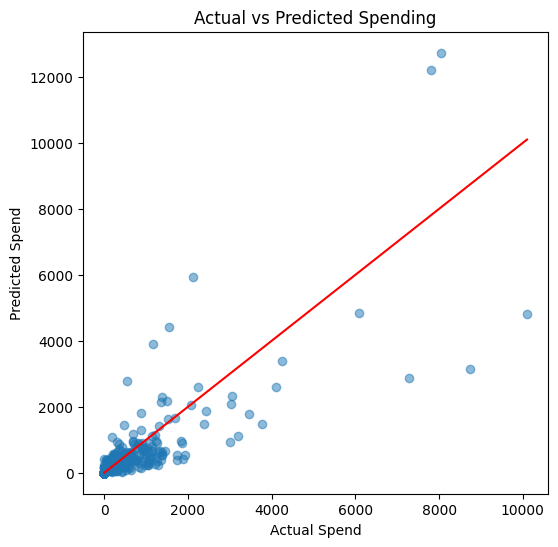

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Spend")
plt.ylabel("Predicted Spend")
plt.title("Actual vs Predicted Spending")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.show()